In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from datetime import timedelta
from netCDF4 import Dataset, date2num, num2date
import cftime
import glob
import os
import csv
%matplotlib inline
import datetime
import matplotlib.dates as mdates
import matplotlib.dates as md
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

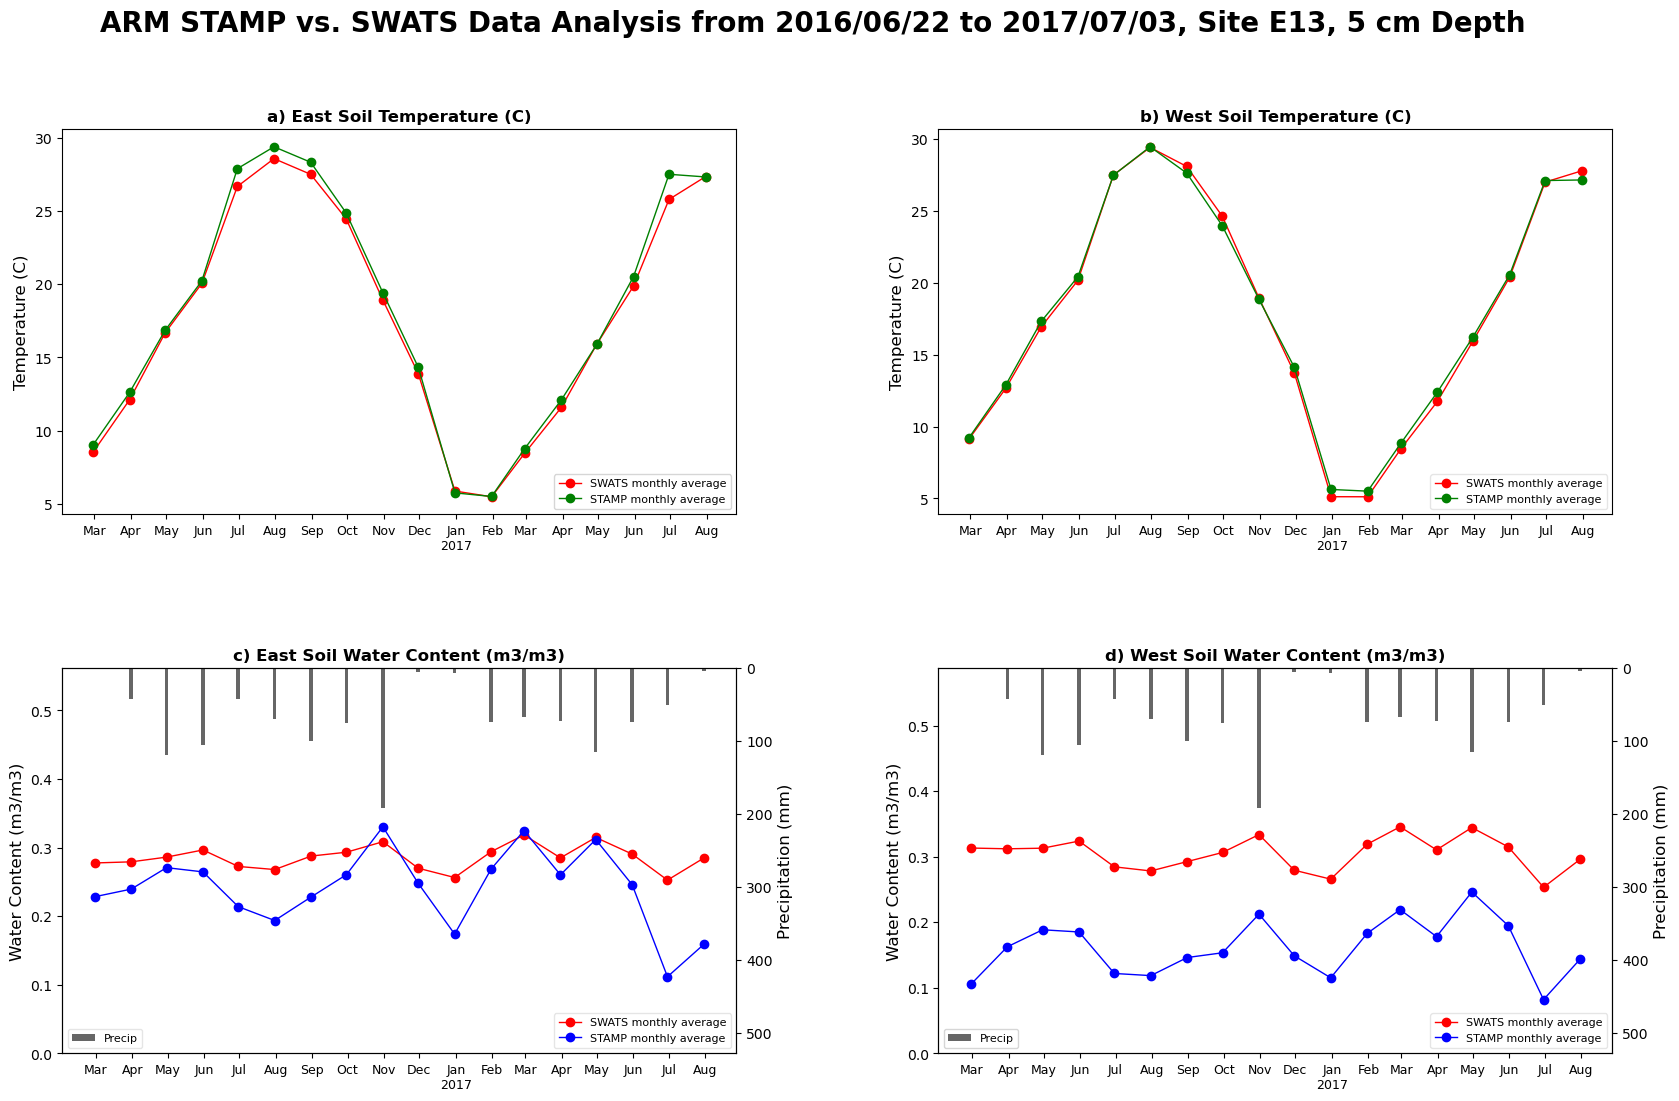

In [3]:
files_swats = sorted(glob.glob('/Users/dave121504/ARM Project/SWATS Files/sgpswats*.nc'))

swats = xr.open_mfdataset(files_swats, combine='by_coords')

files_stamp = sorted(glob.glob('/Users/dave121504/ARM Project/STAMP Files/sgpstamp*.nc'))
stamp = xr.open_mfdataset(files_stamp, combine='by_coords')

files_stamp_precip = sorted(glob.glob('/Users/dave121504/ARM Project/STAMP Precip Files/sgpstamppcp*.nc'))
stamp_precip = xr.open_mfdataset(files_stamp_precip, combine='by_coords')

stamp_precip = stamp_precip['precip']
#stamp_cum = stamp_precip.cumsum()
stamp_avg = stamp_precip.resample(time='1ME').sum()

fig, axes = plt.subplots(2, 2, figsize = (20, 12))

time_swats = swats['time']
time_stamp = stamp['time']

#swats temperature east, monthly average 
swats_tempE = swats['tsoil_e'].isel(depth=0)
stamp_tempE = stamp['soil_temperature_east'].isel(depth=0)
swats_monthly_temp_E = swats_tempE.resample(time='1ME').mean()
stamp_monthly_temp_E = stamp_tempE.resample(time='1ME').mean()


#soil temp east
axes[0,0].plot(swats_monthly_temp_E['time'], swats_monthly_temp_E, color = 'red', linewidth = 1, marker='o', label = 'SWATS monthly average')
axes[0,0].plot(stamp_monthly_temp_E['time'], stamp_monthly_temp_E, color = 'green', linewidth = 1, marker='o', label = 'STAMP monthly average')
axes[0,0].set_ylabel('Temperature (C)', fontsize = 12)
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[0,0].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[0,0].set_title("a) East Soil Temperature (C)", fontweight = 'bold', fontsize = 12)
axes[0,0].legend(loc = "lower right", fontsize = 8)

#soil temp west
swats_tempW = swats['tsoil_w'].isel(depth=0)
stamp_tempW = stamp['soil_temperature_west'].isel(depth=0)
swats_monthly_temp_W = swats_tempW.resample(time='1ME').mean()
stamp_monthly_temp_W = stamp_tempW.resample(time='1ME').mean()
axes[0,1].plot(swats_monthly_temp_W['time'], swats_monthly_temp_W, color = 'red', linewidth = 1, marker='o', label = 'SWATS monthly average')
axes[0,1].plot(stamp_monthly_temp_W['time'], stamp_monthly_temp_W, color = 'green', linewidth = 1,marker='o', label = 'STAMP monthly average')
axes[0,1].set_ylabel('Temperature (C)', fontsize = 12)
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[0,1].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[0,1].set_title("b) West Soil Temperature (C)", fontweight = 'bold', fontsize = 12)
axes[0,1].legend(loc = "lower right", fontsize = 8, framealpha = 0.5)

#Soil moisture east
swats_spec_moist_E = swats['watcont_e'].isel(depth=0)
stamp_spec_moist_E = stamp['soil_specific_water_content_east'].isel(depth=0)
stamp_moist_E = stamp_spec_moist_E / 100
swats_monthly_moist_E = swats_spec_moist_E.resample(time = '1ME').mean()
stamp_monthly_moist_E = stamp_moist_E.resample(time = '1ME').mean()

axes[1,0].plot(swats_monthly_moist_E['time'], swats_monthly_moist_E, color = 'red', linewidth = 1, marker='o', label = 'SWATS monthly average')
axes[1,0].plot(stamp_monthly_moist_E['time'], stamp_monthly_moist_E, color = 'blue', linewidth = 1, marker='o', label = 'STAMP monthly average')
axes[1,0].set_ylabel('Water Content (m3/m3)', fontsize = 12)
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[1,0].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[1,0].set_title("c) East Soil Water Content (m3/m3)", fontweight = 'bold', fontsize = 12)
axes[1,0].set_ylim(0, stamp_monthly_moist_E.max() * 1.7)
axes[1,0].legend(loc = "lower right", fontsize = 8, framealpha = 0.5)

plot_c_precip_E = axes[1,0].twinx()
precip_time = mdates.date2num(pd.to_datetime(stamp_avg['time'].values))
precip_vals = stamp_avg.values

plot_c_precip_E.bar(precip_time, precip_vals, color = 'black', width = 3, alpha = 0.6, label = 'Precip')
plot_c_precip_E.set_ylim(precip_vals.max() * 2.75, 0)
plot_c_precip_E.legend(loc = 'lower left', fontsize = 8, framealpha = 0.5)
plot_c_precip_E.set_ylabel('Precipitation (mm)', fontsize = 12)
#plot_c_precip_E.fill_between(precip_time, precip_vals, 0, color = 'black', alpha = 0.05)

#Soil moisture west
swats_spec_moist_W = swats['watcont_w'].isel(depth=0)
stamp_spec_moist_W = stamp['soil_specific_water_content_west'].isel(depth=0)
stamp_moist_W = stamp_spec_moist_W / 100
swats_monthly_moist_W = swats_spec_moist_W.resample(time = '1ME').mean()
stamp_monthly_moist_W = stamp_moist_W.resample(time = '1ME').mean()

axes[1,1].plot(swats_monthly_moist_W['time'], swats_monthly_moist_W, color = 'red', linewidth = 1, marker='o', label = 'SWATS monthly average')
axes[1,1].plot(stamp_monthly_moist_W['time'], stamp_monthly_moist_W, color = 'blue', linewidth = 1, marker='o',  label = 'STAMP monthly average')
axes[1,1].set_ylabel('Water Content (m3/m3)', fontsize = 12)
axes[1,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[1,1].tick_params(axis = 'x', labelrotation = 45, labelsize = 6)
axes[1,1].set_title("d) West Soil Water Content (m3/m3)", fontweight = 'bold', fontsize = 12)
axes[1,1].set_ylim(0, swats_monthly_moist_W.max() * 1.7)
axes[1,1].legend(loc = "lower right", fontsize = 8, framealpha = 0.5)

plot_d_precip_W = axes[1,1].twinx()
plot_d_precip_W.bar(precip_time, precip_vals, color = 'black', width = 3, alpha = 0.6, label = 'Precip')
plot_d_precip_W.set_ylim(precip_vals.max() * 2.75, 0)
plot_d_precip_W.legend(loc = 'lower left', fontsize = 8)
plot_d_precip_W.set_ylabel('Precipitation (mm)', fontsize = 12)
#plot_d_precip_W.fill_between(precip_time, precip_vals, 0, color = 'black', alpha = 0.05)
fig.suptitle("ARM STAMP vs. SWATS Data Analysis from 2016/06/22 to 2017/07/03, Site E13, 5 cm Depth", fontweight = 'bold', fontsize = 20)           

def month_or_year(x, pos=None):
    date = mdates.num2date(x)
    if date.month == 1:
        return date.strftime('%b\n%Y')
    else:
        return date.strftime('%b')


for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(month_or_year)
    ax.tick_params(axis='x', labelrotation=0, labelsize=9)

plt.subplots_adjust(hspace=0.4, wspace = 0.3)
plt.savefig('2_ARM_monthly_soil_and_precip_temp_analysis', dpi=300, bbox_inches='tight')